<center>
    <h1>
    Exploration - Étape 2
    </h1>
</center>

In [1]:
%%html

<!-- styles d'affichage -->
<style>
    .section_div {
        width:70%;
        height:1.5px;
        border:none;
        color:black;
        background-color:black;
        margin: auto;
        margin-top: 0px;
        margin-bottom: 0px;
    }

    .answer {
        color:blue;
    }

    .question {
        color:red;
    }

    .note {
        color:green;
        font-weight: bold;
    }
</style>

In [2]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [3]:
#
# import utilitaires
#
%matplotlib inline

import audioread
import librosa as rosa
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path
from pprint import pprint
from tqdm.notebook import tqdm

In [4]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

# load dataset explore
explored_df = pd.read_csv(config.get_csv_filename(DatasetType.EXPLORED))

In [5]:
# validation des donnees explorees
print("Dataset shape:", explored_df.shape)

print()

print("Types")
display(explored_df.dtypes.to_frame().T)

print

print("Affichage succint")
display(explored_df.head())

Dataset shape: (1104, 6)

Types


,common_name,primary_label,latitude,longitude,filename,Duration
0,object,object,float64,float64,object,float64


Affichage succint


,common_name,primary_label,latitude,longitude,filename,Duration
0,Barn Swallow,barswa,30.0801,-99.5027,barswa/XC141346.ogg,24.5
1,Barn Swallow,barswa,51.0383,3.9184,barswa/XC142633.ogg,44.9
2,Barn Swallow,barswa,51.0383,3.9184,barswa/XC142794.ogg,71.7
3,Barn Swallow,barswa,50.7380,9.6649,barswa/XC146746.ogg,21.1
4,Barn Swallow,barswa,35.0620,-85.1660,barswa/XC135474.ogg,13.2


<div class="answer">

* Shape est telle qu'attendue (voir 00-jfgagnon-exploration.ipynb/00-jfgagnon-exploration.pdf)
* Types sont tels qu'attendus
* Les attributs sont tel qu'attendus.

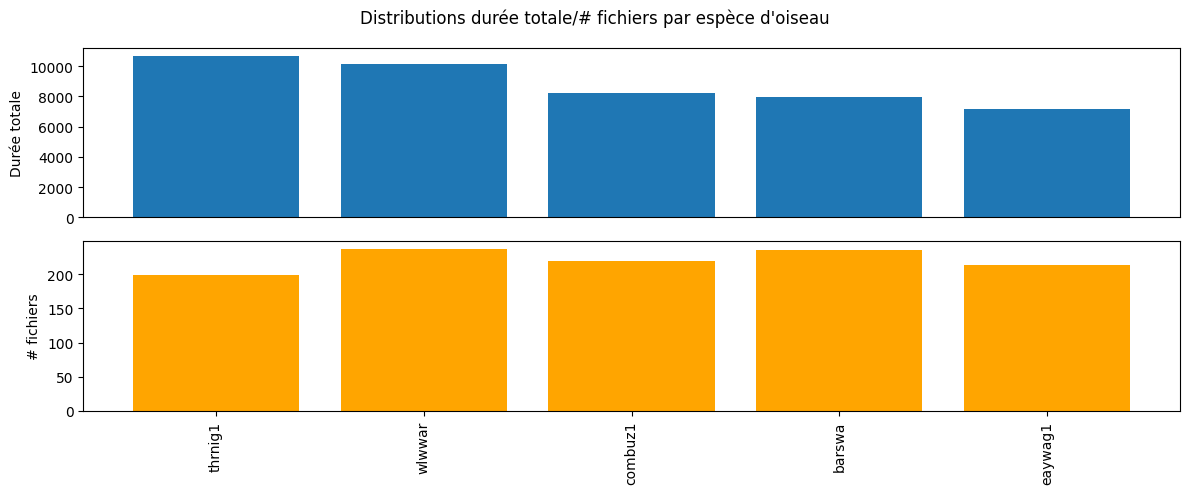


Statistique sommaire de 'Duration' pour toutes les espèces.


count    mean          std     min     25%     50%      75%  \
Duration sum      5.0  8828.0  1509.091851  7156.0  7935.8  8232.7  10114.3   
         count    5.0   220.8    15.817712   199.0   213.0   220.0    235.0   

                    max  
Duration sum    10701.2  
         count    237.0

In [6]:
# regarder nombre de fichiers et duree total par espece
#
groups = explored_df[["primary_label", "Duration"]] \
                    .groupby(by="primary_label")
aggregate = groups.agg({"Duration": ["sum", "count"]}) \
                  .sort_values(by=("Duration", "sum"), ascending=False)
aggregate_count = len(aggregate)

total_duration = aggregate[("Duration", "sum")]
num_samples = aggregate[("Duration", "count")]

STEP = 1
WIDTH = 2

dist_range = range(aggregate_count)
dist_range_step = range(0, aggregate_count, STEP)

indices = [i for i in dist_range]
indices_step = [i for i in dist_range_step]

plt.figure(figsize=(12, 5))

plt.subplot(211)
plt.bar(indices,
        total_duration.iloc[indices])
plt.ylabel("Durée totale")
plt.tick_params(axis="x",
                which="both",
                bottom=False,
                top=False,
                labelbottom=False)

plt.subplot(212)
plt.bar(indices,
        num_samples.iloc[indices],
        color="orange")
plt.ylabel("# fichiers")

plt.gca().set_xticks(indices_step)
plt.gca().set_xticklabels([aggregate.index[i] for i in indices_step], rotation=90)

plt.suptitle("Distributions durée totale/# fichiers par espèce d'oiseau")
plt.tight_layout()
plt.show()

print()

print("Statistique sommaire de 'Duration' pour toutes les espèces.")
display( aggregate.describe().T )

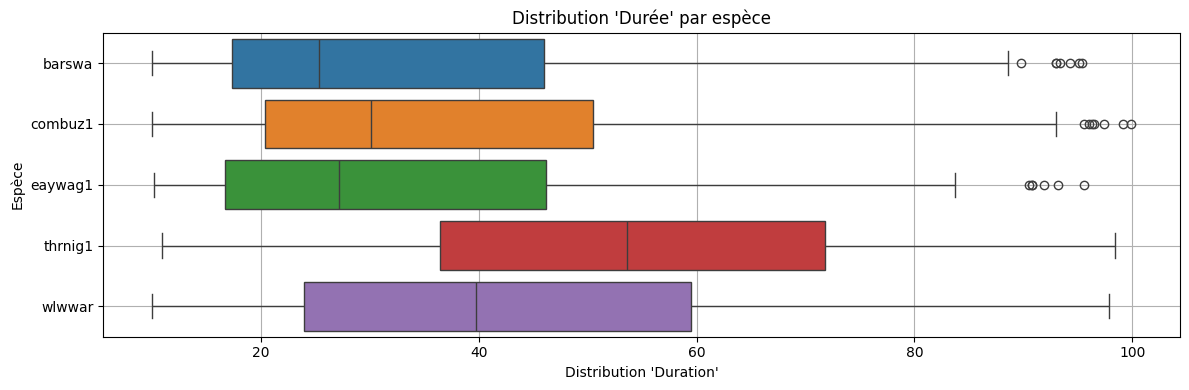

In [7]:
# regarder distribution de la duree par espece
#
duration_dict = {}

species = list(groups.groups.keys())

for i in indices_step:
    primary_label = species[i]
    duration_dict[primary_label] = groups.get_group(primary_label)["Duration"]

plt.figure(figsize=(12, 4))
sns.boxplot(duration_dict, orient="h", ax=plt.gca())
plt.grid()
plt.title("Distribution 'Durée' par espèce")
plt.xlabel("Distribution 'Duration'")
plt.ylabel("Espèce")

plt.tight_layout()
plt.show()

<div class="answer">

* Les distribution ne sont pas balancées (telles qu'attendues).
* 5 espèces tel qu'attendu.

Basé sur les recherches faite dans la littérature, le pipeline d'entraînement aura cette forme:

<div align="center">
  <img src="img/classification-pipeline.png" width=512>
</div>

Le fichier audio source est découpé en segments d'une durée D secondes. Les caractéristiques de chaque segment sont extraites à l'aide du le mel-spectrogram en une image de W mel-bands x H frame. Les caractéristiques de S segments consécutifs seront regroupées pour effectuer la classification. Ce regroupement est nécessaire dû à la nature de nos données. En effet, le label est connu pour chaque fichier et non pour chaque segment. C'est le weak-labeling et la technique d'apprentissage qui l'adresse se nomme multiple instance learning.

Noter que les segments peuvent se chevaucher (et le seront) comme l'illustre la figure suivante:

<div align="center">
  <img src="img/segments.png" width=512>
</div>

Le problème de classification audio est maintenant un problème de vision par ordinateur. Nous dénoterons S segments consécutifs par groupe. On cherche donc une façon de resampler les données en groupes de tel sorte qu'elles couvrent l'ensemble des données originales mais aussi résulte en un nouvel ensemble de données balancées.

Basé sur les recherches faite dans la littérature, un segment de 3 secondes est un bon point de départ pour les chants d'oiseaux. En assumant qu'un groupe à une durée de 6 secondes (correspond à 3 segments de 3s avec overlap de 50%) nous pouvons continuer l'analyse pour identifier le nombres de samples par espèces. L'objectif est de "couvrir" tous les fichiers audio (pour avoir une plus grande diversité auditive) sans trop d'overlap entre les groupes (répétition de samples).

Durée d'un groupe
$$
    \begin{align}
        Duration_{groupe} &= (1 - \%_{overlap}) Duration_{segment} (S - 1) + Duration_{segment} \\
        &= Duration_{segment} \left[   (1 - \%_{overlap}) (S - 1) + 1 \right] \\
    \end{align}
$$

In [8]:

SEGMENT_COUNT = 3 # S
SEGMENT_DURATION = 3.0
SEGMENT_OVERLAP = 0.5

def group_duration():
    return SEGMENT_DURATION * ( (1.0 - SEGMENT_OVERLAP) * (SEGMENT_COUNT - 1) + 1)

def non_overlaping_group_count(duration, group_duration):
    return math.floor(duration / group_duration)

stats = aggregate[("Duration", "sum")].describe().iloc[2:]
stats2 = aggregate[("Duration", "count")].describe().iloc[2:]

stats_group = stats.apply( non_overlaping_group_count, args=(group_duration(),))
stats_group.name = "# groupes/espèce"

stats_group2 = stats_group * aggregate_count
stats_group2.name = "# groupes total pour datset"

stats_df = pd.concat([stats2, stats, stats_group, stats_group2], axis=1)

print("# espèces:", aggregate_count)
print("Durée groupe:", group_duration())
print("Durée segment:", SEGMENT_DURATION, "(s) - # segments:", SEGMENT_COUNT, "- overlap:", SEGMENT_OVERLAP)

print()

print("Quantité de groupes selon stats")
display(stats_df.T)

# espèces: 5
Durée groupe: 6.0
Durée segment: 3.0 (s) - # segments: 3 - overlap: 0.5

Quantité de groupes selon stats


,std,min,25%,50%,75%,max
"(Duration, count)",15.817712,199.0,213.0,220.0,235.0,237.0
"(Duration, sum)",1509.091851,7156.0,7935.8,8232.7,10114.3,10701.2
# groupes/espèce,251.000000,1192.0,1322.0,1372.0,1685.0,1783.0
# groupes total pour datset,1255.000000,5960.0,6610.0,6860.0,8425.0,8915.0


<div class="answer">

* En se basant sur la médiane, 1300 groupes de 6 secondes ferait en sorte que ~50% des espèces serait oversampled ~50% des  undersampled.

<div class="answer">

Donc si on résume, preprocess:
1. Faire log-melspectrogram de tous les fichier audio au complet
2. Mettre information de durée par espece ; comme si c'était 1 seul gros fichier
3. Avec une série de Halton, on sample un start de groupe ; ce start est remappé sur la bonne partie du bon fichier avec l'info trouvée en 2.

Dernier élément ; on veut peut-être s'assurer qu'il y a présence d'audio intéressant. Peut-être faire un filtre par medianne pour voir s'il y a qqch. Ou faire une visualisation qui montre la moyenne/variance des spectrogrammes par espèce pour voir s'il y a des régions non couvertes.

Train/test/validation : split les groupes (ne pas oublier stratification).